In [7]:
import sys
sys.path.append('../..')

from src import utils
import src.channelCoding as cc
from pymongo import MongoClient
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import matplotlib as mpl
import matplotlib.patheffects as pe
import hmac


# MongoDB connection


clients = MongoClient('mongodb://localhost:27017/')
dbs = []
for db in clients.list_database_names():
    if db.startswith('r0_r1_SC_alpha'):
        dbs.append(clients[db]['destination, phase_1'])


# --- alpha from your docs ---------------------------------------------------
def infer_alpha(coll):
    return float(coll.find_one({})["config"]["ALPHA"])

def infer_msg_tag(coll):
    temp = coll.find_one({})["config"]
    len_MAC_encoded = int(np.ceil(256/temp["MAC_REP"]/temp["MAC_LDPC"]))
    len_msg = int(np.ceil((len_MAC_encoded - 512) * temp['MSG_CODE_RATE']))
    msg_str = temp['PAYLOAD'][:len_msg//8]
    msg_encoded = cc.encode_LDPC(utils.string_to_bits(msg_str), Codeword_length=len_MAC_encoded)
    tag = hmac.new(key=temp['MAC_KEY'].encode('utf-8'),
                   msg= msg_str.encode('utf-8'),
                     digestmod=temp['MAC_SHA']).hexdigest()
    tag_bits = utils.hex_to_bits(tag)
    tag_encoded = cc.encode_LDPC(tag_bits, Codeword_length=int(np.ceil(256/temp["MAC_LDPC"])))
    tag_encoded = np.repeat(tag_encoded, int(np.ceil(1//temp["MAC_REP"])))
    return msg_encoded, tag_encoded

msg_bits, tag_bits = infer_msg_tag(dbs[0])  # Assuming all have the same config

dfs = {}
for db in dbs:
    dfs[str(infer_alpha(db))] = pd.DataFrame(list(db.find({})))



I0000 00:00:1755010992.403300 1890723 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 20619 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3090, pci bus id: 0000:01:00.0, compute capability: 8.6


/tmp/ipykernel_1890723/360213822.py:463: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  tag_cmap = mpl.cm.get_cmap(tag_cmap_name)


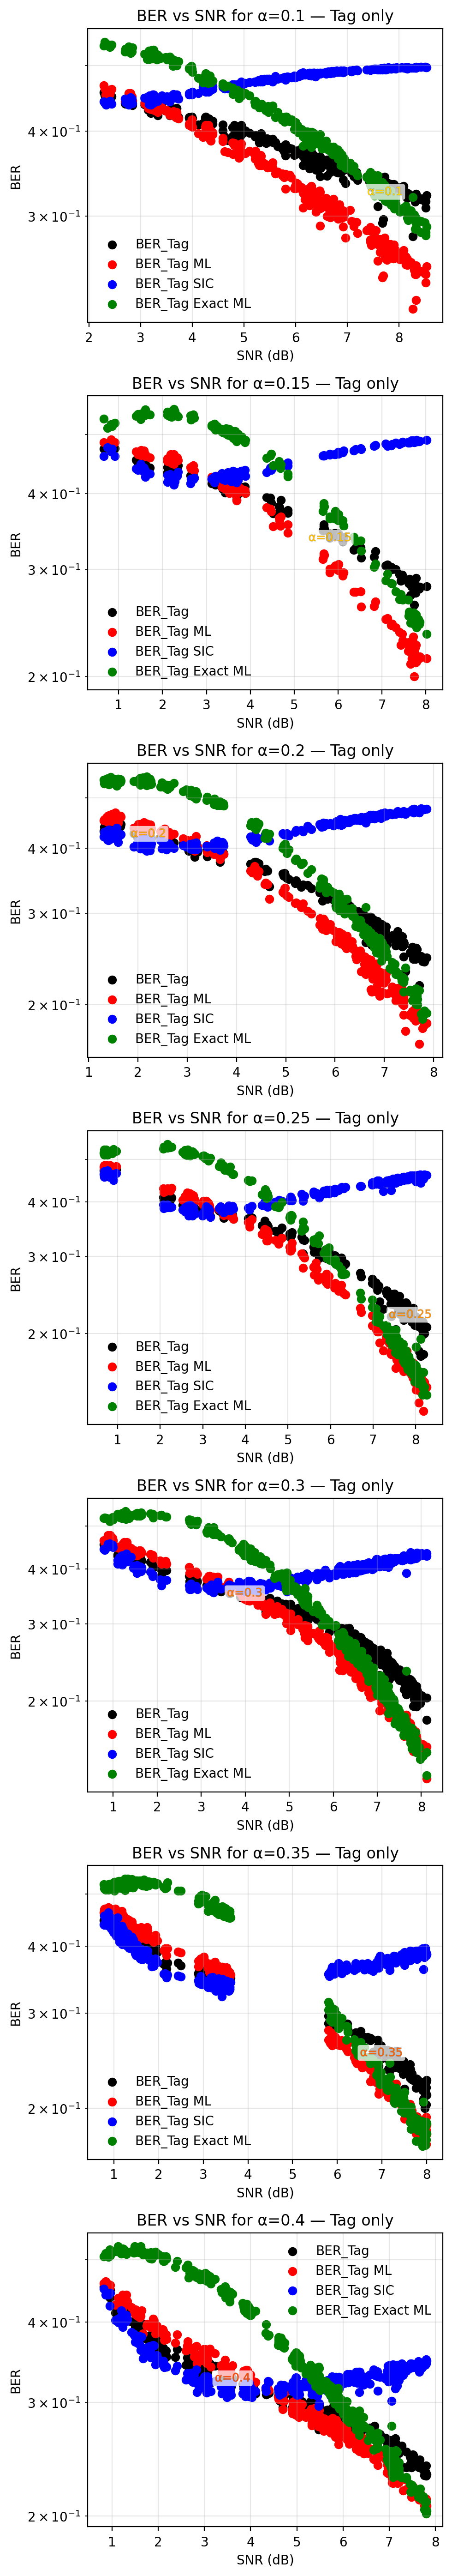

In [10]:
from scipy.special import erfc


# Define Q-function
def qfunc(x):
    return 0.5 * erfc(x / np.sqrt(2))
# Error rate function
def error_rate(l, R, p):

    # Avoid log(0) issues by adding a very small number when needed.
    p = np.where(p == 0, 1e-19, p)
    one_minus_p = 1 - p
    C = 1 + p * np.log2(p) + one_minus_p * np.log2(one_minus_p)
    denom = np.log2(one_minus_p / p)
    term = np.sqrt(l / (p * one_minus_p)) * ((C - R) / denom)
    return qfunc(term)
import numpy as np

def decode_superposed_fsk(
    E0, E1, snr, sigma_n2, alpha, snr_is_db=True, return_confidence=True
):
    """
    E0, E1: 1D arrays (or lists) of per-symbol energies in f0 and f1 bins
    snr: scalar SNR for these symbols (linear or dB)
    sigma_n2: scalar noise variance per bin
    alpha: fraction of total symbol power allocated to the WEAK layer (0..1)
    snr_is_db: if True, 'snr' is in dB and will be converted to linear
    return_confidence: if True, also return a per-symbol confidence score

    Returns:
      msg_bits: np.ndarray of 0/1 (strong layer: 0=>f0, 1=>f1)
      tag_bits: np.ndarray of 0/1 (weak  layer: 0=>f0, 1=>f1)
      confidences (optional): np.ndarray in [0,1], larger => more confident
    """
    E0 = np.asarray(E0, dtype=float)
    E1 = np.asarray(E1, dtype=float)
    assert E0.shape == E1.shape

    # SNR (linear) and power model
    snr_lin = 10**(snr/10.0) if snr_is_db else float(snr)
    P_tot   = snr_lin * sigma_n2              # total signal power per symbol
    P_str   = (1.0 - alpha) * P_tot           # strong layer power
    P_weak  = alpha * P_tot                   # weak  layer power
    N       = sigma_n2                        # mean noise energy in an empty bin

    # Expected mean energies for each hypothesis (E0_hat, E1_hat)
    # H00: strong f0 + weak f0  => f0: P_tot + N,     f1: N
    # H01: strong f0 + weak f1  => f0: P_str + N,     f1: P_weak + N
    # H10: strong f1 + weak f0  => f0: P_weak + N,    f1: P_str + N
    # H11: strong f1 + weak f1  => f0: N,             f1: P_tot + N
    means = np.array([
        [P_tot + N,     N        ],  # H00
        [P_str + N,     P_weak + N],  # H01
        [P_weak + N,    P_str + N],  # H10
        [N,             P_tot + N],  # H11
    ])  # shape (4, 2)

    # For speed, compute squared errors to each hypothesis, vectorized
    # errs[h, i] = (E0[i]-means[h,0])^2 + (E1[i]-means[h,1])^2
    E = np.stack([E0, E1], axis=0)            # (2, n)
    diffs = E[None, :, :] - means[:, :, None] # (4, 2, n)
    errs  = np.sum(diffs**2, axis=1)          # (4, n)

    # Best hypothesis per symbol
    idx = np.argmin(errs, axis=0)             # (n,)
    # Map hypothesis index -> (msg_bit, tag_bit)
    # H00 -> (0,0), H01 -> (0,1), H10 -> (1,0), H11 -> (1,1)
    map_bits = np.array([[0,0],[0,1],[1,0],[1,1]])
    decoded = map_bits[idx]
    msg_bits = decoded[:,0]
    tag_bits = decoded[:,1]

    if not return_confidence:
        return msg_bits, tag_bits

    # Simple confidence: margin between best and second-best hypothesis
    sorted_errs = np.sort(errs, axis=0)       # (4, n)
    margin = sorted_errs[1] - sorted_errs[0]  # (n,)
    # Normalize margin to [0,1] for convenience (robust min-max)
    if margin.size > 0:
        lo, hi = np.percentile(margin, [10, 90])
        denom = max(hi - lo, 1e-12)
        conf = np.clip((margin - lo) / denom, 0.0, 1.0)
    else:
        conf = margin
    return msg_bits, tag_bits, conf


# ---- Example usage with one row from your DataFrame ----
# Suppose a row has: r0 (list of energies in f0), r1 (list in f1),
# SNR (likely dB), sigma_n2, and you know alpha.
row = dfs['0.15'].iloc[170]
msg, tag, conf = decode_superposed_fsk(row['r0'], row['r1'],
                                       snr=row['SNR'], sigma_n2=row['sigma_n2'],
                                       alpha=0.15, snr_is_db=True)
row['SNR'], row['BER_msg'],np.sum(msg!=msg_bits)/len(msg_bits), row['BER_tag'],np.sum(tag!=tag_bits)/len(msg_bits)



import numpy as np

# ---- utilities ---------------------------------------------------------------
def _to_linear_snr(snr, snr_is_db):
    return 10**(snr/10.0) if snr_is_db else float(snr)

def _gauss_ll(x, P, sigma2):
    """
    Log-likelihood for energy x given signal power P and noise variance sigma2,
    using a Gaussian approx to the noncentral-chi^2 energy.
      mean = P + sigma2
      var  = sigma2**2 + 2*P*sigma2
    Returns log p(x | P, sigma2) up to an additive constant independent of P.
    """
    mu = P + sigma2
    var = sigma2**2 + 2.0*P*sigma2
    var = np.maximum(var, 1e-18)
    return -0.5*((x - mu)**2/var + np.log(var))

def _logsumexp(a, axis=0):
    m = np.max(a, axis=axis, keepdims=True)
    return (m + np.log(np.sum(np.exp(a - m), axis=axis, keepdims=True))).squeeze(axis)

# ---- expected powers for the four hypotheses --------------------------------
# H00: strong→f0, weak→f0
# H01: strong→f0, weak→f1
# H10: strong→f1, weak→f0
# H11: strong→f1, weak→f1
def _hypothesis_powers(P_str, P_weak):
    return np.array([
        [P_str + P_weak, 0.0          ],  # H00
        [P_str,          P_weak       ],  # H01
        [P_weak,         P_str        ],  # H10
        [0.0,            P_str + P_weak],  # H11
    ], dtype=float)  # shape (4, 2)

_map_bits = np.array([[0,0],[0,1],[1,0],[1,1]], dtype=int)  # H -> (msg, tag)


def _text_on_curve(ax, x, y, text, color, frac=0.78,
                   bbox_fc="white", bbox_alpha=0.75):
    """
    Place 'text' ON the curve around the given fractional position (0..1),
    rotated to match the local slope. Adds a rounded, semi-opaque background.
    """
    if len(x) < 2:
        return
    xi = np.asarray(x); yi = np.asarray(y)
    idx = int(np.clip(frac * (len(xi)-1), 1, len(xi)-2))

    # rotation angle using log10(y) because the y-axis is logarithmic
    dy = np.log10(yi[idx+1]) - np.log10(yi[idx-1])
    dx = xi[idx+1] - xi[idx-1]
    angle = 0#np.degrees(np.arctan2(dy, dx))

    ax.text(
        xi[idx], yi[idx], text,
        color=color, fontsize=9, ha="center", va="center",
        rotation=angle, rotation_mode="anchor",
        zorder=5,
        bbox=dict(facecolor=bbox_fc, alpha=bbox_alpha,
                  edgecolor="none", boxstyle="round,pad=0.2"),
        # small halo as extra insurance against busy backgrounds
        path_effects=[pe.withStroke(linewidth=0.5, foreground="black", alpha=0.25)]
    )

# ---- Joint ML decoder --------------------------------------------------------
def decode_superposed_fsk_ml(E0, E1, snr, sigma_n2, alpha, snr_is_db=True, return_confidence=True):
    """
    Joint maximum-likelihood over the 4 hypotheses using variance-weighted likelihoods.
    """
    E0 = np.asarray(E0, float); E1 = np.asarray(E1, float)
    assert E0.shape == E1.shape
    snr_lin = _to_linear_snr(snr, snr_is_db)
    P_tot   = snr_lin * sigma_n2
    P_str   = (1.0 - alpha) * P_tot
    P_weak  = alpha * P_tot

    H = _hypothesis_powers(P_str, P_weak)  # (4,2)
    # log-likelihood for each hypothesis and symbol
    ll0 = np.stack([_gauss_ll(E0, H[h,0], sigma_n2) for h in range(4)])  # (4,n)
    ll1 = np.stack([_gauss_ll(E1, H[h,1], sigma_n2) for h in range(4)])  # (4,n)
    LL  = ll0 + ll1  # (4,n)

    idx = np.argmax(LL, axis=0)  # best hypothesis per symbol
    bits = _map_bits[idx]
    msg, tag = bits[:,0], bits[:,1]

    if not return_confidence:
        return msg, tag

    # confidence = margin between best and second-best log-likelihood
    sortedLL = np.sort(LL, axis=0)
    margin = sortedLL[-1] - sortedLL[-2]
    # normalize to [0,1] for convenience
    lo, hi = np.percentile(margin, [5,95]) if margin.size else (0,1)
    conf = np.clip((margin - lo)/max(hi-lo,1e-12), 0.0, 1.0)
    return msg, tag, conf

# ---- Soft SIC decoder --------------------------------------------------------
def decode_superposed_fsk_sic(E0, E1, snr, sigma_n2, alpha, snr_is_db=True):
    """
    Decode strong (msg) by marginalizing over weak (equal priors),
    then decode weak (tag) conditioned on the msg decision.
    Optionally subtract strong POWER before weak decision (power-domain SIC).
    """
    E0 = np.asarray(E0, float); E1 = np.asarray(E1, float)
    snr_lin = _to_linear_snr(snr, snr_is_db)
    P_tot   = snr_lin * sigma_n2
    P_str   = (1.0 - alpha) * P_tot
    P_weak  = alpha * P_tot

    H = _hypothesis_powers(P_str, P_weak)  # (4,2)
    ll0 = np.stack([_gauss_ll(E0, H[h,0], sigma_n2) for h in range(4)])  # (4,n)
    ll1 = np.stack([_gauss_ll(E1, H[h,1], sigma_n2) for h in range(4)])  # (4,n)
    LL  = ll0 + ll1  # (4,n)

    # Marginalize over weak bit for msg decision:
    # msg=0 -> hypotheses H00,H01; msg=1 -> H10,H11
    LL_msg0 = _logsumexp(LL[[0,1], :], axis=0) - np.log(2.0)
    LL_msg1 = _logsumexp(LL[[2,3], :], axis=0) - np.log(2.0)
    msg = (LL_msg1 > LL_msg0).astype(int)

    # Optional power subtraction (power-domain SIC)
    E0_res = E0.copy()
    E1_res = E1.copy()
    # subtract expected strong POWER from the decided bin (clip at 0)
    E0_res = np.where(msg==0, np.clip(E0_res - P_str, 0.0, None), E0_res)
    E1_res = np.where(msg==1, np.clip(E1_res - P_str, 0.0, None), E1_res)

    # Now decode weak given msg:
    # if msg=0: compare H00 vs H01; if msg=1: compare H10 vs H11
    # We re-evaluate LL on residual energies using ONLY weak power.
    Hw = _hypothesis_powers(0.0, P_weak)
    ll0w = np.stack([_gauss_ll(E0_res, Hw[h,0], sigma_n2) for h in range(4)])
    ll1w = np.stack([_gauss_ll(E1_res, Hw[h,1], sigma_n2) for h in range(4)])
    LLw  = ll0w + ll1w

    tag0 = (LLw[1] > LLw[0]).astype(int)   # when msg=0: H01 vs H00
    tag1 = (LLw[3] > LLw[2]).astype(int)   # when msg=1: H11 vs H10
    tag  = np.where(msg==0, tag0, tag1)

    return msg, tag

# ---------------- Example ----------------
row = dfs['0.15'].iloc[170]  # α = 0.15
msg_ml, tag_ml, conf = decode_superposed_fsk_ml(row['r0'], row['r1'],
                                                snr=row['SNR'], sigma_n2=row['sigma_n2'],
                                                alpha=0.15, snr_is_db=True)
msg_sic, tag_sic = decode_superposed_fsk_sic(row['r0'], row['r1'],
                                             snr=row['SNR'], sigma_n2=row['sigma_n2'],
                                             alpha=0.15, snr_is_db=True)

row['SNR'], row['BER_msg'],np.sum(msg_ml!=msg_bits)/len(msg_bits), row['BER_tag'],np.sum(tag_ml!=tag_bits)/len(msg_bits)
# row['SNR'], row['BER_msg'],np.sum(msg_sic!=msg_bits)/len(msg_bits), row['BER_tag'],np.sum(tag_sic!=tag_bits)/len(msg_bits)




# ---------- stable log I0 (modified Bessel) ----------
def _log_i0(z):
    z = np.asarray(z, dtype=float)
    # Piecewise: series for small z, asymptotic for large z
    small = z < 3.75
    out = np.empty_like(z)
    # Cephes-like poly for log(i0) via i0 series then log
    t = z[small] / 3.75
    t2 = t*t
    i0_small = (1.0 + t2*(3.5156229 + t2*(3.0899424 + t2*(1.2067492 +
                 t2*(0.2659732 + t2*(0.0360768 + t2*0.0045813))))))
    out[small] = np.log(i0_small)
    # large-z: log(i0(z)) ~ z - 0.5*log(2πz) + 1/(8z) - 9/(128 z^3)
    zl = z[~small]
    out[~small] = zl - 0.5*np.log(2*np.pi*zl) + (1/(8*zl)) - (9/(128*zl**3))
    return out

# ---------- exact log-likelihood for energy ----------
def _ll_energy(x, P, sigma2):
    """
    Exact log p(x | P, sigma2) for complex tone-in-noise energy (Rice / noncentral-chi^2_2).
    x, P can be arrays; sigma2 is scalar.
    """
    x = np.asarray(x, float)
    P = np.asarray(P, float)
    inv = 1.0 / sigma2
    # handle P=0 (pure noise) separately to avoid 0*log(0) etc.
    ll = -np.log(sigma2) - x*inv
    nonzero = P > 0.0
    if np.any(nonzero):
        xn = x[nonzero]; Pn = P[nonzero]
        z = 2.0*np.sqrt(xn*Pn)*inv
        ll_nz = -np.log(sigma2) - (xn+Pn)*inv + _log_i0(z)
        ll[nonzero] = ll_nz
    return ll

def _to_lin_snr(snr, is_db=True):
    return 10**(snr/10.0) if is_db else float(snr)

def _hyp_powers(Ps, Pw):
    # H: [ [E0_power, E1_power], ... ]
    return np.array([
        [Ps+Pw, 0.0   ],  # H00: strong f0, weak f0
        [Ps,    Pw    ],  # H01: strong f0, weak f1
        [Pw,    Ps    ],  # H10: strong f1, weak f0
        [0.0,   Ps+Pw ],  # H11: strong f1, weak f1
    ], dtype=float)

_map_bits = np.array([[0,0],[0,1],[1,0],[1,1]], dtype=int)

# ---------- Exact joint-ML decoder (noncentral-chi^2) ----------
def decode_superposed_fsk_exact_ml(E0, E1, snr, sigma_n2, alpha, snr_is_db=True, priors=None, return_confidence=True):
    """
    E0, E1: arrays of per-symbol energies in f0 and f1 bins
    snr, sigma_n2, alpha as before. 'priors' optional length-4 prior over hypotheses.
    """
    E0 = np.asarray(E0, float); E1 = np.asarray(E1, float)
    snr_lin = _to_lin_snr(snr, snr_is_db)
    Ptot = snr_lin * sigma_n2
    Ps   = (1.0 - alpha) * Ptot
    Pw   = alpha * Ptot

    H = _hyp_powers(Ps, Pw)  # shape (4,2)
    # log-likelihood per hypothesis for all symbols
    ll0 = np.stack([_ll_energy(E0, H[h,0], sigma_n2) for h in range(4)])  # (4,n)
    ll1 = np.stack([_ll_energy(E1, H[h,1], sigma_n2) for h in range(4)])  # (4,n)
    LL  = ll0 + ll1  # (4,n)

    # Optional non-uniform priors over hypotheses
    if priors is not None:
        priors = np.asarray(priors, float)
        priors /= priors.sum()
        LL = LL + np.log(priors)[:, None]

    idx = np.argmax(LL, axis=0)
    bits = _map_bits[idx]
    msg, tag = bits[:,0], bits[:,1]

    if not return_confidence:
        return msg, tag

    # confidence via log-likelihood margin
    sortedLL = np.sort(LL, axis=0)
    margin = sortedLL[-1] - sortedLL[-2]
    lo, hi = np.percentile(margin, [5,95]) if margin.size else (0,1)
    conf = np.clip((margin - lo)/max(hi-lo,1e-12), 0.0, 1.0)
    return msg, tag, conf

# ---------- (Optional) LLR-gated SIC to avoid high-SNR blow-ups ----------
def decode_superposed_fsk_llr_gated_sic(E0, E1, snr, sigma_n2, alpha, snr_is_db=True, gate_db=2.0):
    """
    Subtract strong layer ONLY if the message LLR exceeds gate_db (natural log units converted from dB-like margin).
    This keeps the low-SNR benefit of SIC while avoiding error-prop at high SNR.
    """
    E0 = np.asarray(E0, float); E1 = np.asarray(E1, float)
    snr_lin = _to_lin_snr(snr, snr_is_db)
    Ptot = snr_lin * sigma_n2
    Ps   = (1.0 - alpha) * Ptot
    Pw   = alpha * Ptot

    H = _hyp_powers(Ps, Pw)
    ll0 = np.stack([_ll_energy(E0, H[h,0], sigma_n2) for h in range(4)])
    ll1 = np.stack([_ll_energy(E1, H[h,1], sigma_n2) for h in range(4)])
    LL  = ll0 + ll1

    # message LLR: log p(msg=1 | E) - log p(msg=0 | E)
    # msg=0 => H00,H01 ; msg=1 => H10,H11  (equal priors on tag)
    def _logsumexp(a, axis=0):
        m = np.max(a, axis=axis, keepdims=True)
        return (m + np.log(np.sum(np.exp(a-m), axis=axis, keepdims=True))).squeeze(axis)

    l_msg1 = _logsumexp(LL[[2,3], :], axis=0) - np.log(2.0)
    l_msg0 = _logsumexp(LL[[0,1], :], axis=0) - np.log(2.0)
    LLR = l_msg1 - l_msg0
    msg = (LLR > 0).astype(int)

    # Gate: subtract strong power only if |LLR| >= gate
    gate = (gate_db/10.0) * np.log(10.0)  # convert "dB-like" margin to natural log
    do_sub = np.abs(LLR) >= gate

    E0_res = E0.copy(); E1_res = E1.copy()
    E0_res = np.where((msg==0) & do_sub, np.clip(E0_res - Ps, 0.0, None), E0_res)
    E1_res = np.where((msg==1) & do_sub, np.clip(E1_res - Ps, 0.0, None), E1_res)

    # Tag decision on residuals (exact likelihood with only Pw)
    Hw = _hyp_powers(0.0, Pw)
    ll0w = np.stack([_ll_energy(E0_res, Hw[h,0], sigma_n2) for h in range(4)])
    ll1w = np.stack([_ll_energy(E1_res, Hw[h,1], sigma_n2) for h in range(4)])
    LLw  = ll0w + ll1w
    tag0 = (LLw[1] > LLw[0]).astype(int)
    tag1 = (LLw[3] > LLw[2]).astype(int)
    tag  = np.where(msg==0, tag0, tag1)

    return msg, tag


# Example usage with one row from your DataFrame
row = dfs['0.15'].iloc[170]  # α = 0.15
msg_exact, tag_exact, conf_exact = decode_superposed_fsk_exact_ml(row['r0'], row['r1'],
                                                snr=row['SNR'], sigma_n2=row['sigma_n2'],
                                                alpha=0.15, snr_is_db=True)










for df in dfs.keys():
    dfs[df]['BER_msg_ml'] = np.nan
    dfs[df]['BER_tag_ml'] = np.nan
    dfs[df]['BER_msg_sic'] = np.nan
    dfs[df]['BER_tag_sic'] = np.nan
    dfs[df]['BER_msg_exact'] = np.nan
    dfs[df]['BER_tag_exact'] = np.nan

for df in dfs.keys():
    for i, row in dfs[df].iterrows():
        msg_ml, tag_ml = decode_superposed_fsk_ml(row['r0'], row['r1'],
                                                  snr=row['SNR'], sigma_n2=row['sigma_n2'],
                                                  alpha=float(df), snr_is_db=True, return_confidence=False)
        msg_sic, tag_sic = decode_superposed_fsk_sic(row['r0'], row['r1'],
                                                     snr=row['SNR'], sigma_n2=row['sigma_n2'],
                                                     alpha=float(df), snr_is_db=True)
        msg_exact, tag_exact, conf_exact = decode_superposed_fsk_exact_ml(row['r0'], row['r1'],
                                                snr=row['SNR'], sigma_n2=row['sigma_n2'],
                                                alpha=float(df), snr_is_db=True)
        
        
        dfs[df].at[i, 'BER_msg_exact'] = np.sum(msg_exact != msg_bits) / len(msg_bits)
        dfs[df].at[i, 'BER_tag_exact'] = np.sum(tag_exact != tag_bits) / len(tag_bits)
        
        dfs[df].at[i, 'BER_msg_ml'] = np.sum(msg_ml != msg_bits) / len(msg_bits)
        dfs[df].at[i, 'BER_tag_ml'] = np.sum(tag_ml != tag_bits) / len(tag_bits)

        dfs[df].at[i, 'BER_msg_sic'] = np.sum(msg_sic != msg_bits) / len(msg_bits)
        dfs[df].at[i, 'BER_tag_sic'] = np.sum(tag_sic != tag_bits) / len(tag_bits)



# plot the tag BER for ML and BER_tag
# plot_ber_vs_snr_by_alpha([dbs[0]], save_to="ber_vs_snr_alpha_on_line_ml.png")

# modifying the plot_BER_vs_snr_by_alpha function to show ML and SIC results for tag only and every alpha will be a dufferet subplot
def plot_ber_vs_snr_by_alpha(dfs, save_to=None, compare = True,
                             msg_cmap_name='summer', tag_cmap_name="autumn"):
    series = []
    for alpha, df in dfs.items():
        g = df.copy()
        if not g.empty:
            series.append((float(alpha), g))
    if not series:
        print("No data to plot.")
        return
    # sort so darker (low α) are drawn first, brighter on top
    series.sort(key=lambda x: x[0])
    alphas = [a for a, _ in series]
    a_min, a_max = min(alphas), max(alphas)
    if a_max == a_min:
        a_max = a_min + 1e-12
    norm = mpl.colors.Normalize(vmin=.05*a_min, vmax=1.4*a_max)
    tag_cmap = mpl.cm.get_cmap(tag_cmap_name)   
    fig, axs = plt.subplots(len(series), 1, figsize=(5, 4*len(series)), dpi=200)
    if len(series) == 1:
        axs = [axs]  # ensure axs is always a list
    for ax, (a, g) in zip(axs, series):
        # invert intensity so higher α => brighter
        shade = 1.0 - norm(a)
        tag_color = tag_cmap(shade)

        ax.scatter(g["SNR"], g["BER_tag"], 
                color='black', label="BER_Tag")

        # write α on each line (slightly different positions to reduce overlap)
        _text_on_curve(ax, g["SNR"], g["BER_tag"], f"α={a:g}", tag_color, frac=0.78)
        if compare:
            ax.scatter(g["SNR"], g["BER_tag_ml"], 
                    color='red', label="BER_Tag ML")
            ax.scatter(g["SNR"], g["BER_tag_sic"], 
                     color='blue', label="BER_Tag SIC")
            ax.scatter(g["SNR"], g["BER_tag_exact"], 
                     color='green', label="BER_Tag Exact ML")
            # ax.scatter(g["SNR"], g["BER_tag_GammaML"], 
            #          color='orange', label="BER_Tag Gamma ML")
            
        # styling
        ax.set_yscale("log")
        ax.set_xlabel("SNR (dB)")
        ax.set_ylabel("BER")
        ax.set_title(f"BER vs SNR for α={a:g} — Tag only")
        ax.grid(True, which="both", alpha=0.3)  
        # tiny legend just for type
        from matplotlib.lines import Line2D
        ax.legend( loc="best", frameon=False)
    fig.tight_layout()
    if save_to:
        fig.savefig(save_to, dpi=220, bbox_inches="tight")
    plt.show()  
# Usage:
plot_ber_vs_snr_by_alpha(dfs, save_to="ber_vs_snr_alpha_on_line_ml_sic.png", compare=True)

## Machine Learnng

In [11]:
# ---------------- feature engineering ----------------
def _snr_to_lin(snr_db): 
    return 10.0**(np.asarray(snr_db, float)/10.0)

def _make_symbol_features(E0, E1, snr_db, sigma2, alpha):
    """
    Return feature matrix X of shape (n_symbols, d).
    """
    E0 = np.asarray(E0, float); E1 = np.asarray(E1, float)
    n  = E0.size
    snr_lin = _snr_to_lin(snr_db)
    snr_lin = np.repeat(snr_lin, n) if np.isscalar(snr_lin) else np.asarray(snr_lin, float)
    sigma2  = np.repeat(float(sigma2), n)
    alpha   = np.repeat(float(alpha), n)

    S = E0 + E1
    D = E0 - E1
    eps = 1e-12

    feats = np.column_stack([
        E0, E1,
        np.log1p(E0), np.log1p(E1),
        S, D,
        D/(S+eps),       # contrast (signed)
        E0/(S+eps),      # soft argmax
        E1/(S+eps),
        E0/(sigma2+eps), E1/(sigma2+eps),  # noise-normalized
        D/(sigma2+eps),
        snr_lin, np.sqrt(snr_lin),
        sigma2, alpha
    ])
    return feats

# map 4-class label <-> bits
_MAP_BITS = np.array([[0,0],[0,1],[1,0],[1,1]], dtype=int)   # H00,H01,H10,H11
def _bits_to_class(msg, tag):
    # inverse mapping: (0,0)->0, (0,1)->1, (1,0)->2, (1,1)->3
    return (msg<<1) + tag

# ---------------- dataset builder from dfs ----------------
def build_dataset_from_dfs(dfs, snr_is_db=True, gt_msg_col='msg_bits', gt_tag_col='tag_bits'):
    """
    Concatenate all rows from all dfs into one training set (only rows that have GT).
    Returns X, y, meta list with (df_key, row_idx, n_symbols, alpha, snr, sigma2).
    """
    Xs, ys, metas = [], [], []
    for k, df in dfs.items():
        # alpha from the dict key or column
        alpha = float(k) if 'alpha' not in df.columns else float(df['alpha'].iloc[0])
        for i, r in df.iterrows():
            if gt_msg_col not in r or gt_tag_col not in r:
                continue
            msg = np.asarray(r[gt_msg_col], dtype=int)
            tag = np.asarray(r[gt_tag_col], dtype=int)
            if msg.size == 0 or tag.size == 0 or msg.size != tag.size:
                continue
            E0, E1 = np.asarray(r['r0'], float), np.asarray(r['r1'], float)
            assert E0.size == msg.size == E1.size
            snr = r['SNR'] if snr_is_db else 10*np.log10(r['SNR']+1e-12)
            Xs.append(_make_symbol_features(E0, E1, snr, r['sigma_n2'], alpha))
            ys.append(_bits_to_class(msg, tag))
            metas.append((k, i, msg.size, alpha, r['SNR'], r['sigma_n2']))
    if not Xs:
        raise ValueError("No rows with ground-truth bits found.")
    X = np.vstack(Xs)
    y = np.concatenate(ys)
    return X, y, metas

# ---------------- train a 4-class model ----------------
def train_decoder_classifier(X, y, random_state=42):
    """
    Tries HistGradientBoosting; falls back to LogisticRegression if unavailable.
    Returns (clf, label_names).
    """
    try:
        from sklearn.ensemble import HistGradientBoostingClassifier
        clf = HistGradientBoostingClassifier(
            max_depth=None,
            max_iter=300,
            learning_rate=0.08,
            l2_regularization=1e-4,
            class_weight="balanced",
            random_state=random_state
        )
    except Exception:
        from sklearn.linear_model import LogisticRegression
        from sklearn.preprocessing import StandardScaler
        from sklearn.pipeline import make_pipeline
        clf = make_pipeline(
            StandardScaler(with_mean=False),
            LogisticRegression(max_iter=2000, class_weight="balanced", multi_class="auto")
        )
    clf.fit(X, y)
    return clf, np.array(['H00','H01','H10','H11'])

# ---------------- apply model to a row ----------------
def decode_row_with_model(row, alpha, clf, snr_is_db=True):
    E0 = np.asarray(row['r0'], float)
    E1 = np.asarray(row['r1'], float)
    snr = row['SNR'] if snr_is_db else 10*np.log10(row['SNR']+1e-12)
    X   = _make_symbol_features(E0, E1, snr, row['sigma_n2'], alpha)
    probs = clf.predict_proba(X) if hasattr(clf, "predict_proba") else None
    yhat = clf.predict(X)
    bits = _MAP_BITS[yhat]
    msg, tag = bits[:,0], bits[:,1]
    conf = None if probs is None else np.max(probs, axis=1)  # per-symbol confidence
    return msg, tag, conf

# ---------------- enrich all dfs ----------------
def add_ml_decoder_columns(dfs, snr_is_db=True, gt_msg_col='msg_bits', gt_tag_col='tag_bits'):
    # 1) build dataset and train once on all alphas (generalist model)
    X, y, metas = build_dataset_from_dfs(dfs, snr_is_db=snr_is_db, gt_msg_col=gt_msg_col, gt_tag_col=gt_tag_col)
    clf, labels = train_decoder_classifier(X, y)

    # 2) apply to each row and add columns
    for k, df in dfs.items():
        alpha = float(k) if 'alpha' not in df.columns else float(df['alpha'].iloc[0])

        def _apply(r):
            msg, tag, conf = decode_row_with_model(r, alpha, clf, snr_is_db=snr_is_db)
            out = {
                'msg_MLlearn': msg,
                'tag_MLlearn': tag,
                'conf_MLlearn_mean': (float(np.mean(conf)) if conf is not None else np.nan),
                'conf_MLlearn_med':  (float(np.median(conf)) if conf is not None else np.nan),
            }
            # BERs if GT available
            if gt_msg_col in r and isinstance(r[gt_msg_col], (list, np.ndarray)):
                gt_m = np.asarray(r[gt_msg_col], int)
                out['BER_msg_MLlearn'] = float(np.mean(msg != gt_m)) if gt_m.size else np.nan
            else:
                out['BER_msg_MLlearn'] = np.nan
            if gt_tag_col in r and isinstance(r[gt_tag_col], (list, np.ndarray)):
                gt_t = np.asarray(r[gt_tag_col], int)
                out['BER_tag_MLlearn'] = float(np.mean(tag != gt_t)) if gt_t.size else np.nan
            else:
                out['BER_tag_MLlearn'] = np.nan
            return pd.Series(out)

        newcols = df.apply(_apply, axis=1)
        dfs[k] = pd.concat([df, newcols], axis=1)

    return dfs

# ---------------- quick usage ----------------
dfs = add_ml_decoder_columns(dfs, snr_is_db=True, gt_msg_col='msg_bits', gt_tag_col='tag_bits')
dfs['0.40'][['BER_Tag','BER_tag_ML','BER_tag_SIC','BER_tag_MLlearn']].head()


ValueError: No rows with ground-truth bits found.